In [1]:
#import libraries and define variables for Black-Scholes

import numpy as np
from scipy.stats import norm

from fredapi import Fred
fred =Fred(api_key='853f892eabd7b99abf77d8084e8f1afa')
ten_year_treasury_rate = fred.get_series_latest_release('GS10')/100
r = ten_year_treasury_rate.iloc[-1]
print("Risk free rate:", r)                     #Risk free rate
S = 30                       #Underlying price
print("Underlying price is:", S)
K = 40                       #strike price
print("Strike price is:",K)
T = 240/365                  #time to expiration
print("Time to expiration:",T)
sigma = 0.30                 #volatility
print("Volatility:",sigma)

def blackScholes(r,S,K,T,sigma,type="C"):
    "Calculate the BlackScholes option price for a call/put"
    d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    try:
        if type == "C":
            price = S*norm.cdf(d1,0,1) - K*np.exp(-r*T)*norm.cdf(d2,0,1)
        elif type == "P":
            price = K*np.exp(-r*T)*norm.cdf(-d2,0,1)-S*norm.cdf(-d1,0,1)
        return price
    except:
        print("Please confirm all option parameters")

print("Option price is:", round(blackScholes(r,S,K,T,sigma,type="P"),2))


Risk free rate: 0.041299999999999996
Underlying price is: 30
Strike price is: 40
Time to expiration: 0.6575342465753424
Volatility: 0.3
Option price is: 9.53


In [2]:
#Calculating options greeks using black-scholes model

#DELTA 

from py_vollib.black_scholes import black_scholes as bs
from py_vollib.black_scholes.greeks.analytical import delta,gamma,vega,theta,rho

def delta_calc(r,S,K,T,sigma,type="C"):
    "Calculate delta of an option"
    d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
    
    try:
        if type == "C":
            delta_calc = norm.cdf(d1,0,1) 
        elif type == "P":
            delta_calc = -norm.cdf(-d1,0,1) 
        return delta_calc, delta(type,S,K,T,r,sigma)
    except:
        print("Please confirm all option parameters")

#GAMMA


def gamma_calc(r,S,K,T,sigma,type="C"):
    "Calculate gamma of an option"
    d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
    
    try:
        
        gamma_calc = norm.pdf(d1,0,1)/(S*sigma*np.sqrt(T))
        
        return gamma_calc, gamma(type,S,K,T,r,sigma)
    except:
        print("Please confirm all option parameters")

#VEGA

def vega_calc(r,S,K,T,sigma,type="C"):
    "Calculate the vega of an option"
    d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    try:
        
        vega_calc = S*norm.pdf(d1,0,1)*np.sqrt(T) 
       
        return vega_calc, vega(type,S,K,T,r,sigma)
    except:
        print("Please confirm all option parameters")

#THETA

def theta_calc(r,S,K,T,sigma,type="C"):
    "Calculate the theta of an option"
    d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    try:
        if type == "C":
            theta_calc = -S*norm.pdf(d1,0,1)*sigma/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2,0,1)
        elif type == "P":
            theta_calc = -S*norm.pdf(d1,0,1)*sigma/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(d2,0,1)
        return theta_calc, theta(type,S,K,T,r,sigma)
    except:
        print("Please confirm all option parameters")

#RHO

def rho_calc(r,S,K,T,sigma,type="C"):
    "Calculate the rho of an option"
    d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    try:
        if type == "C":
            rho_calc = K*T*np.exp(-r*T)*norm.cdf(d2,0,1)
        elif type == "P":
            rho_calc = -K*T*np.exp(-r*T)*norm.cdf(-d2,0,1)
        return rho_calc, rho(type,S,K,T,r,sigma)
    except:
        print("Please confirm all option parameters")
option_type = 'C'
print("Option price: ", round(blackScholes(r,S,K,T,sigma,option_type), 3))
print("     Delta:   ", round(delta_calc(r,S,K,T,sigma,option_type)[0], 3))
print("     Gamma:   ", round(gamma_calc(r,S,K,T,sigma,option_type)[0], 3))
print("     Vega:    ", round(vega_calc(r,S,K,T,sigma,option_type)[0], 3))
print("     Theta:   ", round(theta_calc(r,S,K,T,sigma,option_type)[0], 3))
print("     Rho:     ", round(rho_calc(r,S,K,T,sigma,option_type)[0], 3))


Option price:  0.601
     Delta:    0.171
     Gamma:    0.035
     Vega:     6.184
     Theta:    -1.598
     Rho:      2.982


In [3]:
#Binomial options pricing

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csc_matrix
from scipy.stats import bernoulli
from scipy.optimize import fsolve
from scipy.stats import norm

%matplotlib inline

#  Manual process for simple two-step tree

S0 = 100        #  Our initial stock price
t = 1           #  Time to expiration in years
u = 1.05        #  Assumed up and down percentages
d = 1/u
p = 0.6         #  Probability of an up move
S_u = u * S0    #  Stock price at expiration
S_d = d * S0

K = 102.5   #  Option strike price

# risk-free rate
from fredapi import Fred
fred =Fred(api_key='853f892eabd7b99abf77d8084e8f1afa')
ten_year_treasury_rate = fred.get_series_latest_release('GS10')/100
r = ten_year_treasury_rate.iloc[-1]

C_u = S_u - K   #  Call price at up node
C_d = 0         #  Call price at down node

C = np.exp(-r * t) * ( p*C_u + (1-p)*C_d)       #Call price at t = 0
print(C)


1.4393118365952098


16.658296751553824


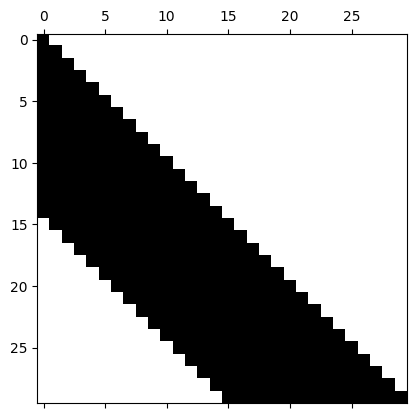

In [4]:
#Binomail pricing for multi-level tree
import numpy as np
import matplotlib.pyplot as plt

N = 30          #  Define the number of layers


t = 1           #  Time to expiration
t = t / (N - 1)


S0 = 100        # Iniital stock price
K = 102.5       #strike price
# risk-free rate
from fredapi import Fred
fred =Fred(api_key='853f892eabd7b99abf77d8084e8f1afa')
ten_year_treasury_rate = fred.get_series_latest_release('GS10')/100
r = ten_year_treasury_rate.iloc[-1]

#  Assume a volatility and calculate the size of an up move, down move, and probability
sigma = 0.4
u = np.exp(sigma * np.sqrt(t))
d = 1/u
p = (np.exp(r * t) - d) / (u - d)

#  Create some empty matrices to hold our stock and call prices.
stock_prices = np.zeros( (N, N) )
call_prices = np.zeros( (N, N) )

#  Put our initial price in the matrix
stock_prices[0,0] = S0


for i in range(1, N ):
    M = i + 1
    stock_prices[i, 0] = d * stock_prices[i-1, 0]
    for j in range(1, M ):
        stock_prices[i, j] = u * stock_prices[i - 1, j - 1]

#  Calculate the call price at expiration
expiration = stock_prices[-1,:] - K
expiration.shape = (expiration.size, )
expiration = np.where(expiration >= 0, expiration, 0)

#  Set the last row of the call matrix to our expiration values
call_prices[-1,:] =  expiration

#  Backpropagate to fill out our tree
for i in range(N - 2,-1,-1):
    for j in range(i + 1):
        call_prices[i,j] = np.exp(-r * t) * ((1-p) * call_prices[i+1,j] + p * call_prices[i+1,j+1])


plt.spy(call_prices)
print(call_prices[0,0])

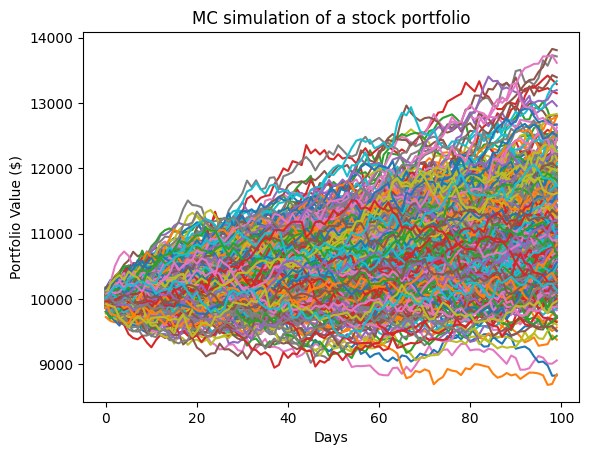

VaR_5 $132.91
CVaR_5 $451.27


In [5]:
# Monte-Carlo simulation for options pricing
import math
import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import scipy.stats as stats
import matplotlib.pyplot as plt



def get_data(stocks, start, end):
    
    stockData = yf.download(stocks, start=start, end=end, auto_adjust=True, progress=False)
    stockData = stockData['Close']
    returns = stockData.pct_change()
    meanReturns = returns.mean()
    covMatrix = returns.cov()
    return meanReturns, covMatrix

AUstocks = ['CBA', 'BHP', 'TLS', 'NAB', 'WBC', 'STO']
USstocks = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'AMZN']
stocks = [s + '.AX' for s in AUstocks] + USstocks
stocks = [stock + '.AX' for stock in AUstocks]
endDate = datetime.datetime.now()
startDate = endDate - datetime.timedelta(days=300)

meanReturns, covMatrix = get_data(stocks, startDate, endDate)

weights = np.random.random(len(meanReturns))
weights /= np.sum(weights)

# Monte Carlo Method
mc_sims = 400
T = 100

meanM = np.full(shape=(T, len(weights)), fill_value=meanReturns)
meanM = meanM.T

portfolio_sims = np.full(shape=(T, mc_sims), fill_value=0.0)

initialPortfolio = 10000

for m in range(0, mc_sims):
    Z = np.random.normal(size=(T, len(weights)))
    L = np.linalg.cholesky(covMatrix)
    dailyReturns = meanM + np.inner(L, Z)
    portfolio_sims[:,m] = np.cumprod(np.inner(weights, dailyReturns.T)+1)*initialPortfolio

plt.plot(portfolio_sims)
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Days')
plt.title('MC simulation of a stock portfolio')
plt.show()

def mcVaR(returns, alpha=5):
    if isinstance(returns, pd.Series):
        return np.percentile(returns, alpha)
    else:
        raise TypeError("Expected a pandas data series.")

def mcCVaR(returns, alpha=5):
    if isinstance(returns, pd.Series):
        belowVaR = returns <= mcVaR(returns, alpha=alpha)
        return returns[belowVaR].mean()
    else:
        raise TypeError("Expected a pandas data series.")

portResults = pd.Series(portfolio_sims[-1,:])

VaR = initialPortfolio - mcVaR(portResults, alpha=5)
CVaR = initialPortfolio - mcCVaR(portResults, alpha=5)

print('VaR_5 ${}'.format(round(VaR, 2)))
print('CVaR_5 ${}'.format(round(CVaR, 2)))



Implied Volatility is :  54.0 %
x_vals length: 8
y_vals length: 8


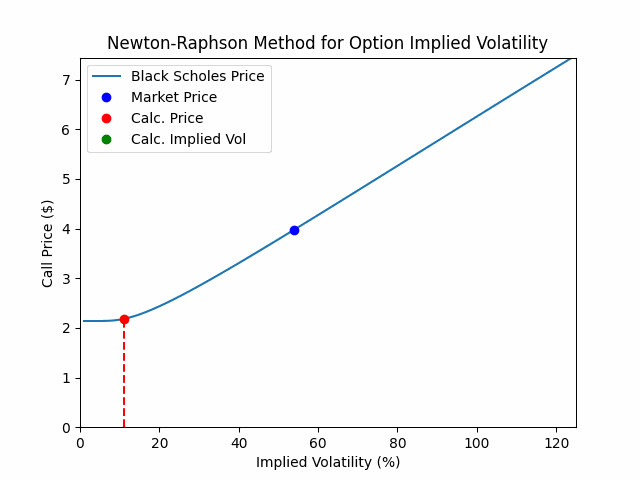

In [20]:
#IMPLIED VOLATILITY 

from py_vollib.black_scholes import black_scholes as bs
from py_vollib.black_scholes.greeks.analytical import vega
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

from IPython.display import HTML, Image # For GIF
from matplotlib import rc
rc('animation', html='jshtml')


def implied_vol(S0, K, T, r, market_price, flag='c', tol=0.00001):
    """Compute the implied volatility of a European Option
        S0: initial stock price
        K:  strike price
        T:  maturity
        r:  risk-free rate
        market_price: market observed price
        tol: user choosen tolerance
    """
    max_iter = 200 #max number of iterations
    vol_old = 0.30 #initial guess

    for k in range(max_iter):
        bs_price = bs(flag, S0, K, T, r, vol_old)
        Cprime =  vega(flag, S0, K, T, r, vol_old)*100
        C = bs_price - market_price
        vol_new = vol_old - C/Cprime
        bs_new = bs(flag, S0, K, T, r, vol_new)

        if (abs(vol_old - vol_new) < tol or abs(bs_new - market_price) < tol):
            break
        vol_old = vol_new

    implied_vol = vol_old
    return implied_vol

S0, K, T, r = 30, 28, 0.2, 0.025
market_price = 3.97
implied_vol_est = implied_vol(S0, K, T, r, market_price, flag='c')
print("Implied Volatility is : ", round(implied_vol_est,2)*100, "%")

#PLOTTING THE CALCULATION


def implied_vol(S0, K, T, r, market_price, flag='c', tol=0.000001):
    """Compute the implied volatility of a European Option
        S0: initial stock price
        K:  strike price
        T:  maturity
        r:  risk-free rate
        market_price: market observed price
        tol: user choosen tolerance
    """
    max_iter = 200
    vol_old = 0.11

    x_vals = []
    y_vals = []

    for k in range(max_iter):
        bs_price = bs(flag, S0, K, T, r, vol_old)
        Cprime = vega(flag, S0, K, T, r, vol_old) * 100
        C = bs_price - market_price
        vol_new = vol_old - C / Cprime

        x_vals.append([vol_old * 100, vol_old * 100])
        y_vals.append([0, bs_price])

        bs_new = bs(flag, S0, K, T, r, vol_new)

        x_vals.append([vol_old * 100, vol_new * 100])
        y_vals.append([bs_price, 0])

        if (abs(vol_old - vol_new) < tol):
            break

        vol_old = vol_new

    implied_vol = vol_old
    return implied_vol, x_vals, y_vals


S0, K, T, r, sigma = 30, 28, 0.2, 0.025, 0.3
prices, vols = [], []
for sigma in range(1, 125):
    prices.append(bs('c', S0, K, T, r, sigma / 100))
    vols.append(sigma)

market_price = 3.9790765403377035
implied_vol, x_vals, y_vals = implied_vol(S0, K, T, r, market_price, flag='c')

print(f"x_vals length: {len(x_vals)}")
print(f"y_vals length: {len(y_vals)}")

fig, ax = plt.subplots()
plt.title('Newton-Raphson Method for Option Implied Volatility')
plt.ylabel('Call Price ($)')
plt.xlabel('Implied Volatility (%)')

y1, = ax.plot(vols, prices, label='Black Scholes Price')
y3, = ax.plot([54], [market_price], 'bo', label='Market Price')
y2, = ax.plot([], [], 'r--')
y4, = ax.plot([], [], 'ro', label='Calc. Price')
y5, = ax.plot([], [], 'go', label='Calc. Implied Vol')
y6, = ax.plot([], [], 'g--')


def init():
    ax.set_xlim(0, 125)
    ax.set_ylim(0, max(prices))
    y2.set_data([], [])
    y4.set_data([], [])
    y5.set_data([], [])
    y6.set_data([], [])
    return y2, y4, y5, y6


def update(frame):
    if frame >= len(x_vals):
        return y2, y4, y5, y6

    if (frame % 2) == 0:
        y2.set_data(x_vals[frame], y_vals[frame])
        y4.set_data([x_vals[frame][1]], [y_vals[frame][1]]) 
    else:
        y6.set_data(x_vals[frame], y_vals[frame])
        y5.set_data([x_vals[frame][1]], [y_vals[frame][1]])  
    return y2, y4, y5, y6


anim = animation.FuncAnimation(fig, update, frames=len(x_vals),
                                init_func=init, interval=750,
                                repeat=True, blit=False)

ax.legend(loc='upper left')

from IPython.display import Image

anim._init_drawn = False
plt.close(fig)          

anim.save('implied_vol_nr.gif', writer='pillow', fps=2)
Image('implied_vol_nr.gif')


